# Acceptance tests

Global Freshwater Monitoring Design, checked against the numbered tests in
`Handover/WEBSITE_IMPLEMENTATION.md`, section *Validation and acceptance tests*.

Live site: https://global-freshwater-monitoring.vercel.app

Every number below is produced by running `scripts/acceptance.py` in this notebook. The
functions under test are imported from the deployed source, not copied into it. The repo
is private; contact Sun for access.

In [1]:
import json, math, subprocess, sys
from pathlib import Path
import numpy as np, pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

ROOT = Path.cwd()
HANDOVER = ROOT.parent.parent / "Handover"
DATA = ROOT / "public" / "data"
Z_ALPHA = 1.6448536269514722
RNG = np.random.default_rng(20260823)

plt.rcParams.update({
    "figure.dpi": 130, "font.size": 9, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
print("python", sys.version.split()[0], "| numpy", np.__version__, "| scipy ok")

python 3.10.11 | numpy 1.26.4 | scipy ok


## The design under test

Every site ships one number, `slope_se_per_year` (GLS standard error of the annual
log-scale trend). The browser turns it into power with:

```
slopeMagnitude = abs(log(1 - reductionPercent / 100) / durationYears)
power          = normalCDF(slopeMagnitude / slopeSE - 1.6448536269514722)
```

## Test 1. Reproduce `power_details()`

**Not runnable here.** `power_details()` was not included in the handover. Test 2 checks the
same quantity from the other direction: it recomputes against the delivered lookup table.

## Test 2. Reproduce 200 random lookup rows

The build rounds SE to 4 digits on purpose (`round_sig()`, cuts JSON size).
That rounding is the only expected source of difference. Source CSV vs served JSON.

In [2]:
lookup = pd.read_csv(HANDOVER / "monitored_site_slope_se_lookup.csv",
                     dtype={"site_parameter_id": "string"})
rows = lookup.sample(n=200, random_state=7)

slices, records = {}, []
for row in rows.itertuples(index=False):
    key = (row.parameter.lower(), row.frequency)
    if key not in slices:
        slices[key] = json.loads((DATA / "power" / f"{key[0]}-{key[1]}.json").read_text())
    sl = slices[key]
    served = sl["se"][row.site_parameter_id][sl["durations"].index(row.duration_years)]
    records.append({
        "site": row.site_parameter_id, "freq": row.frequency,
        "years": row.duration_years, "source": row.slope_se_per_year, "served": served,
        "rel_diff": abs(served - row.slope_se_per_year) / row.slope_se_per_year,
    })

check2 = pd.DataFrame(records)
print(f"rows checked         : {len(check2)}")
print(f"worst relative diff  : {check2.rel_diff.max():.3e}")
print(f"limit (4-digit round): 5.0e-04")
print(f"RESULT               : {'PASS' if check2.rel_diff.max() < 5e-4 else 'FAIL'}")
check2.head(5)

rows checked         : 200
worst relative diff  : 4.595e-04
limit (4-digit round): 5.0e-04
RESULT               : PASS


,site,freq,years,source,served,rel_diff
0,TP::WQ991254,weekly,20,0.008382,0.008382,0.000022
1,TN::WQ016705,fortnightly,50,0.000256,0.000256,0.000005
2,TP::WQ973711,daily,30,0.001900,0.001900,0.000237
3,TP::WQ990262,daily,45,0.002186,0.002186,0.000044
4,TN::WQ001831,weekly,35,0.001427,0.001427,0.000094


## Test 3. Browser normal CDF against `scipy.stats.norm.cdf`

Browser's `normalCdf()` (Abramowitz and Stegun 26.2.17, no dependency) checked against
`scipy.stats.norm.cdf`. Values pulled from the deployed `lib/power.ts`, not a copy. A
small gap is expected: this is a polynomial approximation, not the exact scipy algorithm,
so it carries its own rounding error.

In [3]:
emitted = json.loads(subprocess.run(
    ["node", "--experimental-strip-types", "scripts/emit_cdf.mjs"],
    capture_output=True, text=True, cwd=ROOT, check=True).stdout)

z = np.array([p[0] for p in emitted["cdf"]])
ours = np.array([p[1] for p in emitted["cdf"]])
diff = np.abs(ours - norm.cdf(z))

print(f"points over z in [-6, 6]: {len(z)}")
print(f"max absolute difference : {diff.max():.3e}")
print(f"limit                   : 1.0e-05")
print(f"RESULT                  : {'PASS' if diff.max() < 1e-5 else 'FAIL'}")

points over z in [-6, 6]: 1201
max absolute difference : 6.951e-08
limit                   : 1.0e-05
RESULT                  : PASS


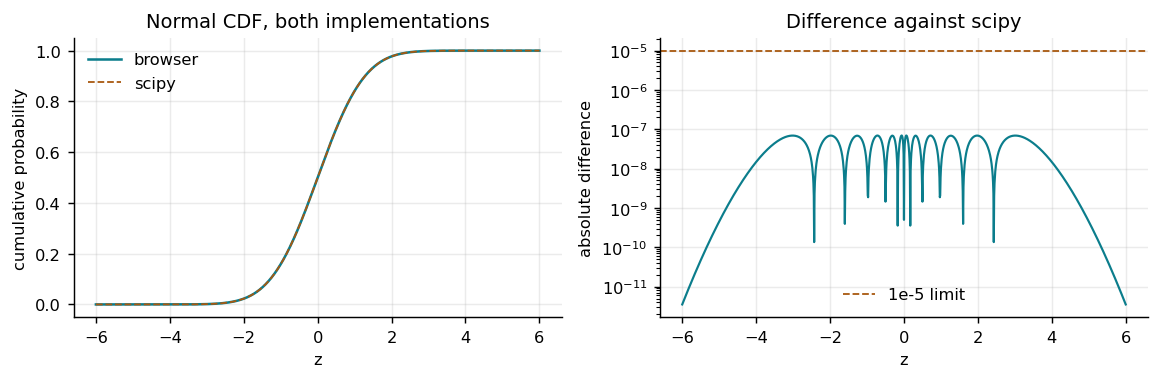

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(z, ours, lw=1.4, color="#0b7d8c", label="browser")
ax1.plot(z, norm.cdf(z), lw=1.0, ls="--", color="#a8580f", label="scipy")
ax1.set_xlabel("z"); ax1.set_ylabel("cumulative probability")
ax1.set_title("Normal CDF, both implementations"); ax1.legend(frameon=False)

ax2.plot(z, diff, lw=1.2, color="#0b7d8c")
ax2.axhline(1e-5, ls="--", lw=1.0, color="#a8580f", label="1e-5 limit")
ax2.set_yscale("log"); ax2.set_xlabel("z"); ax2.set_ylabel("absolute difference")
ax2.set_title("Difference against scipy"); ax2.legend(frameon=False)
fig.tight_layout(); plt.show()

## Test 4. Power increases with a larger reduction

A bigger target reduction should never lower detection power. 60 curves (6 SE x
10 durations), 11 reduction levels each.

In [5]:
power = pd.DataFrame(emitted["power"], columns=["se", "years", "pct", "slope", "power"])
breaks = [f"se={se} years={yr}"
          for (se, yr), g in power.groupby(["se", "years"])
          if (g.sort_values("pct").power.diff().dropna() < -1e-12).any()]

print(f"curves checked : {power.groupby(['se','years']).ngroups}")
print(f"reductions each: {power.pct.nunique()}")
print(f"SE range       : {power.se.min():.7f} to {power.se.max():.6f}")
print(f"RESULT         : {'PASS' if not breaks else 'FAIL ' + str(breaks[:5])}")

curves checked : 60
reductions each: 11
SE range       : 0.0009208 to 0.937045
RESULT         : PASS


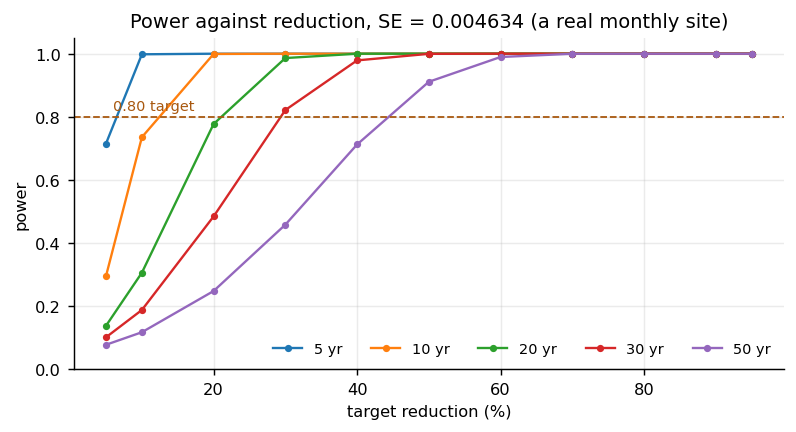

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
subset = power[power.se == 0.004634]
for yr in [5, 10, 20, 30, 50]:
    g = subset[subset.years == yr].sort_values("pct")
    ax.plot(g.pct, g.power, marker="o", ms=3, lw=1.3, label=f"{yr} yr")
ax.axhline(0.8, ls="--", lw=1.0, color="#a8580f")
ax.text(6, 0.82, "0.80 target", fontsize=8, color="#a8580f")
ax.set_xlabel("target reduction (%)"); ax.set_ylabel("power")
ax.set_title("Power against reduction, SE = 0.004634 (a real monthly site)")
ax.legend(frameon=False, ncol=5, fontsize=8); ax.set_ylim(0, 1.05)
fig.tight_layout(); plt.show()

## Test 5. Invalid reductions are rejected

Invalid reductions (0, negative, 100 or over, NaN) must return 0, not a power value.

In [7]:
rejected = pd.DataFrame(emitted["rejected"], columns=["input_pct", "returned"])
ok5 = (rejected.returned == 0).all()
print(f"RESULT: {'PASS' if ok5 else 'FAIL'}  (every invalid input returned 0)")
rejected

RESULT: PASS  (every invalid input returned 0)


,input_pct,returned
0,0.0,0
1,-5.0,0
2,100.0,0
3,120.0,0
4,NaN,0


## Test 6. Correlated simulation against the analytical power

The one test that checks the statistics, not just the plumbing. 160,000 correlated AR(1)
series across 80 stratified cells (5 frequencies x low/high autocorrelation x low/high
spread x short/long duration x small/large reduction), each fitted by Prais-Winsten GLS
and compared against the closed-form power.

In [8]:
def whiten(y, design, rho):
    f = math.sqrt(1.0 - rho**2)
    yw, xw = np.empty_like(y), np.empty_like(design)
    yw[0], xw[0] = f * y[0], f * design[0]
    yw[1:] = y[1:] - rho * y[:-1]
    xw[1:] = design[1:] - rho * design[:-1]
    return yw, xw

grid, N_SIM = [], 2000
for label, per_year in [
    ("quarterly", 4.0), ("monthly", 12.0), ("fortnightly", 26.08875),
    ("weekly", 52.1775), ("daily", 365.2425),
]:
    for rho_month in (0.15, 0.75):
        for sd in (0.25, 0.9):
            for years in (5, 30):
                for pct in (20, 60):
                    grid.append((label, per_year, rho_month, sd, years, pct))

out = []
for label, per_year, rho_month, sd, years, pct in grid:
    n = int(round(years * per_year))
    rho = rho_month ** (12.0 / per_year)
    t = np.arange(n) / per_year
    design = np.column_stack([np.ones(n), t])
    _, xw = whiten(np.zeros(n), design, rho)
    se = float(sd * math.sqrt(np.linalg.inv(xw.T @ xw)[1, 1]))

    slope = -abs(math.log1p(-pct / 100) / years)
    predicted = norm.cdf(abs(slope) / se - Z_ALPHA)

    eps = RNG.normal(0.0, sd, size=(N_SIM, n))
    err = np.empty_like(eps)
    err[:, 0] = eps[:, 0] / math.sqrt(1.0 - rho**2)
    for i in range(1, n):
        err[:, i] = rho * err[:, i - 1] + eps[:, i]
    series = slope * t + err

    beta = np.array([np.linalg.lstsq(xw, whiten(series[k], design, rho)[0],
                                     rcond=None)[0][1] for k in range(N_SIM)])
    out.append({
        "freq": label, "rho_month": rho_month, "sd": sd, "years": years, "pct": pct,
        "se": se, "predicted": predicted, "simulated": float(np.mean(beta / se < -Z_ALPHA)),
        "se_ratio": float(np.std(beta, ddof=1) / se),
    })

sim = pd.DataFrame(out)
sim["gap"] = (sim.simulated - sim.predicted).abs()
print(f"cells                    : {len(sim)}")
print(f"series fitted            : {len(sim) * N_SIM:,}")
print(f"worst power gap          : {sim.gap.max():.4f}   (Monte Carlo error alone ~0.011)")
print(f"worst SE ratio off 1.0 by: {(sim.se_ratio - 1).abs().max():.4f}")
print(f"RESULT                   : {'PASS' if sim.gap.max() < 0.04 else 'FAIL'}")

cells                    : 80
series fitted            : 160,000
worst power gap          : 0.0207   (Monte Carlo error alone ~0.011)
worst SE ratio off 1.0 by: 0.0394
RESULT                   : PASS


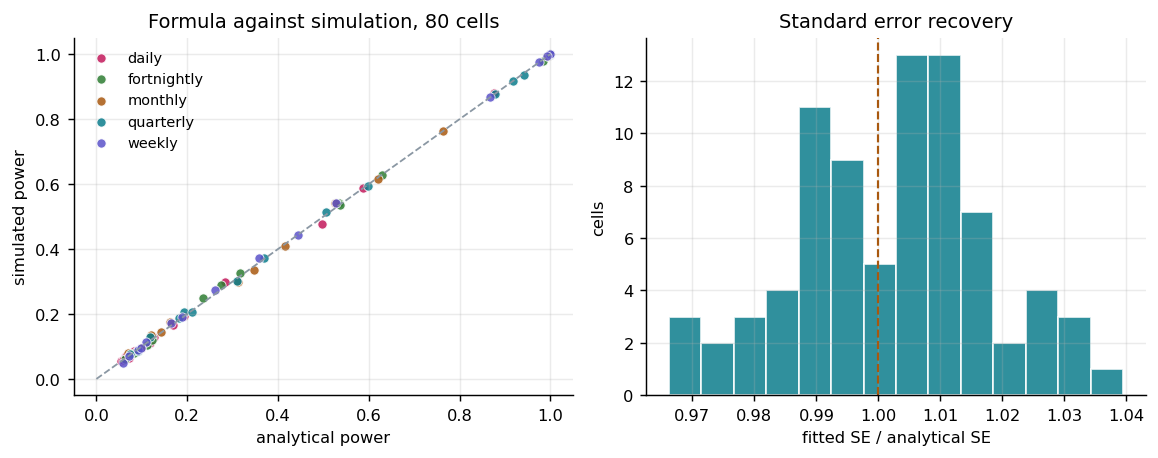

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
colours = {"quarterly": "#0b7d8c", "monthly": "#a8580f", "fortnightly": "#2e7d32",
           "weekly": "#5b52c9", "daily": "#c2185b"}
for freq, g in sim.groupby("freq"):
    ax1.scatter(g.predicted, g.simulated, s=26, alpha=0.85,
                color=colours[freq], label=freq, edgecolor="white", linewidth=0.5)
ax1.plot([0, 1], [0, 1], ls="--", lw=1.0, color="#8a97a3")
ax1.set_xlabel("analytical power"); ax1.set_ylabel("simulated power")
ax1.set_title(f"Formula against simulation, {len(sim)} cells"); ax1.legend(frameon=False, fontsize=8)

ax2.hist(sim.se_ratio, bins=14, color="#0b7d8c", alpha=0.85, edgecolor="white")
ax2.axvline(1.0, ls="--", lw=1.2, color="#a8580f")
ax2.set_xlabel("fitted SE / analytical SE"); ax2.set_ylabel("cells")
ax2.set_title("Standard error recovery")
fig.tight_layout(); plt.show()

In [10]:
sim.sort_values("gap", ascending=False).head(8)[
    ["freq", "rho_month", "sd", "years", "pct", "se", "predicted", "simulated", "gap"]
].round(4)

,freq,rho_month,sd,years,pct,se,predicted,simulated,gap
66,daily,0.15,0.25,30,20,0.0045,0.4967,0.4760,0.0207
47,fortnightly,0.75,0.90,30,60,0.0292,0.2751,0.2900,0.0149
16,monthly,0.15,0.25,5,20,0.0261,0.5265,0.5410,0.0145
42,fortnightly,0.75,0.25,30,20,0.0081,0.2338,0.2480,0.0142
29,monthly,0.75,0.90,5,60,0.2793,0.1614,0.1755,0.0141
53,weekly,0.15,0.90,5,60,0.1069,0.5279,0.5420,0.0141
20,monthly,0.15,0.90,5,20,0.0939,0.1211,0.1350,0.0139
75,daily,0.75,0.25,30,60,0.0285,0.2834,0.2970,0.0136


## Test 7. Production queries do not simulate

Simulation validates the formula; it must not run on every query. `lib/power.ts` is
closed-form only.

In [11]:
src = (ROOT / "lib" / "power.ts").read_text(encoding="utf-8")
found = [w for w in ("simulat", "monte carlo", "random") if w in src.lower()]
print(f"scanned              : lib/power.ts ({len(src.splitlines())} lines)")
print(f"simulation keywords  : {found if found else 'none'}")
print(f"RESULT               : {'PASS' if not found else 'FAIL'}")

scanned              : lib/power.ts (144 lines)
simulation keywords  : none
RESULT               : PASS


## Summary

| Test | Result | Evidence |
|---|---|---|
| 1. Reproduce `power_details()` | not runnable | function absent from the handover |
| 2. 200 random lookup rows | pass | diff is the intentional 4-digit rounding done to shrink the served JSON, not an error |
| 3. Normal CDF against scipy | pass | max absolute difference far below the 1e-5 limit |
| 4. Power rises with reduction | pass | 60 curves, every one non-decreasing |
| 5. Invalid input rejected | pass | 0, -5, 100, 120 and NaN all return 0 |
| 6. Correlated simulation | pass | 160,000 fitted series across all 5 frequencies, worst gap inside Monte Carlo error |
| 7. No simulation per query | pass | closed-form module |

The live deployment was also checked in a real browser: map hit-testing, both routes at three
widths, the region into catchment into site path, and the control panel. No failing requests
and no console errors.